In [1]:
from notebook.services.config import ConfigManager
cm = ConfigManager()
cm.update('livereveal', {
        'width': 1920,
        'height': 1080,
        'scroll': True,
})

{'width': 1920, 'height': 1080, 'scroll': True}

# Problem 0: Who did you work with on this assignment?

DeepSeek writes the code. Hal Yngve guides this process.   Hal Yngve assembles and scrutinizes the output.

# Problem 1 — Failed Supernovae and Accretion Disks

Let’s consider the interesting case of a possible failed supernova. If a shock stalls and loses energy, eventually the star may collapse in on itself to form a black hole. Let’s consider a toy model to understand:  

**(a)** Whether or not there might be an electromagnetic counterpart to this failed explosion, and  
**(b)** How long it might last.  

This problem begins with some order-of-magnitude arguments presented in Quataert et al. (2019).  

### (a) Angular momentum and observable accretion disks

To understand whether we might see anything, we want to know if the material can directly collapse in a spherically symmetric manner onto the black hole, or whether it will have sufficient angular momentum to generate a visible accretion disk that can radiate and be observed.  

**i. Minimum size of an observable accretion disk**  

What is the minimum size of an observable accretion disk around a black hole of mass $M_{\rm BH}$?  

**ii. Specific angular momentum of material in a Keplerian orbit**  

Using this size, calculate the specific angular momentum of material in a Keplerian orbit at this radius, for a black hole of $10 M_\odot$.  

**iii. Angular momentum in the envelope of a Red Supergiant progenitor**  

Now let’s figure out how much angular momentum might be contained in the envelope of our Red Supergiant progenitor. Consider two cases:  

- First, calculate the minimum rotational velocity of the star’s envelope that would provide enough angular momentum to form a visible accretion disk. Consider a $15 M_\odot$ star as a Red Supergiant. If this is a small or large rotation rate compared to, e.g., breakup velocity?  

**iv. Random convective motions in the hydrogen envelope**  

Assume we have no net rotation, and simply have some small net angular momentum generated by the random convective motions in the hydrogen envelope. Assume we are using mixing length theory such that the turbulent eddies are of size $H$, the scale height of the convective zone. How many convective eddies, $N_{\rm edd}$, will “fit” in a shell at radius $r$? Given an average convective overturn velocity of $v_c$, calculate the mean rotational velocity from averaging over many eddies $v_r^2 = v_c^2 / N_{\rm edd}$. Use this to derive an expression for the specific angular momentum of this material. To compare with the value in (ii), assume $H/r \sim 1/3$ and $v_c \sim 10~\rm km/s$.  

**v. Discussion**  

What do you think? Might we see a counterpart?  

### (b) Luminosity and lifetime of the accretion disk

**i. Rough estimate for luminosity of the disk**  

To get a rough estimate for the luminosity of an accretion disk, calculate $dE/dt$ for a blob of material in the disk to be transported from a radius $R_d$ to the origin (i.e., inside the black hole). This should give you a dimensionally correct luminosity.  

**ii. Eddington-limited accretion**  

Assume that the accretion is Eddington limited. In other words, the disk is going to accrete onto the black hole at the accretion rate such that the disk luminosity from (i) is equal to the Eddington luminosity. Use this to calculate the accretion rate in terms of the black hole mass. Assuming the opacity is electron scattering, there should be no other variable in your equation. For our $10 M_\odot$ black hole, what is this value? Use CGS or solar masses per year.  

**iii. Luminosity of the electromagnetic counterpart**  

Now let’s estimate the luminosity of this electromagnetic counterpart, again assuming it is at the Eddington limit.  

**iv. Lifetime of the disk**  

How long will it last? Well, in disks we know that the true luminosity can exceed Eddington by a factor of 10 quite easily, so let’s use an accretion rate that is $10 \dot{M}_{\rm Edd}$, and assume that much of the envelope mass has been lost in the failed explosion, so we need to accrete about $1 M_\odot$ of material. Does this seem plausible?  

**v. Alternative accretion rate estimate**  

If we tried to estimate the accretion rate a different way: Estimate the free-fall timescale of material in the convective envelope. You can look at an actual stellar model, or come up with a very rough estimate for the shell density prior to the explosion. Comment on this discrepancy.  

> Note: The idea of failed SN fallback disks and direct black hole formation is an unsolved problem.


FAILED SUPERNOVA ANALYSIS
Based on Quataert et al. (2019)

PART (a): Angular Momentum and Observable Accretion Disks

--------------------------------------------------
PART (i): Minimum Size of an Observable Accretion Disk
--------------------------------------------------
For M_BH = 10 M☉:
  • Schwarzschild radius: R_s = 29.5 km
  • ISCO radius: R_ISCO = 88.6 km = 3R_s
➤ Minimum observable disk radius: R_min = 88.6 km

--------------------------------------------------
PART (ii): Specific Angular Momentum at ISCO
--------------------------------------------------
For M_BH = 10 M☉:
  • Non-spinning: j_ISCO = 1.08 × 10¹⁷ cm²/s
  • Maximally spinning: j_ISCO = 0.51 × 10¹⁷ cm²/s
➤ Range: 0.51 - 1.08 × 10¹⁷ cm²/s

--------------------------------------------------
PART (iii): Minimum Rotational Velocity
--------------------------------------------------
Red Supergiant: M=15 M☉, R=600 R☉
  • Minimum v_rot = 0.026 km/s
  • Breakup velocity = 69.1 km/s
➤ v_min/v_break = 0.04% of breakup
  ✓ 

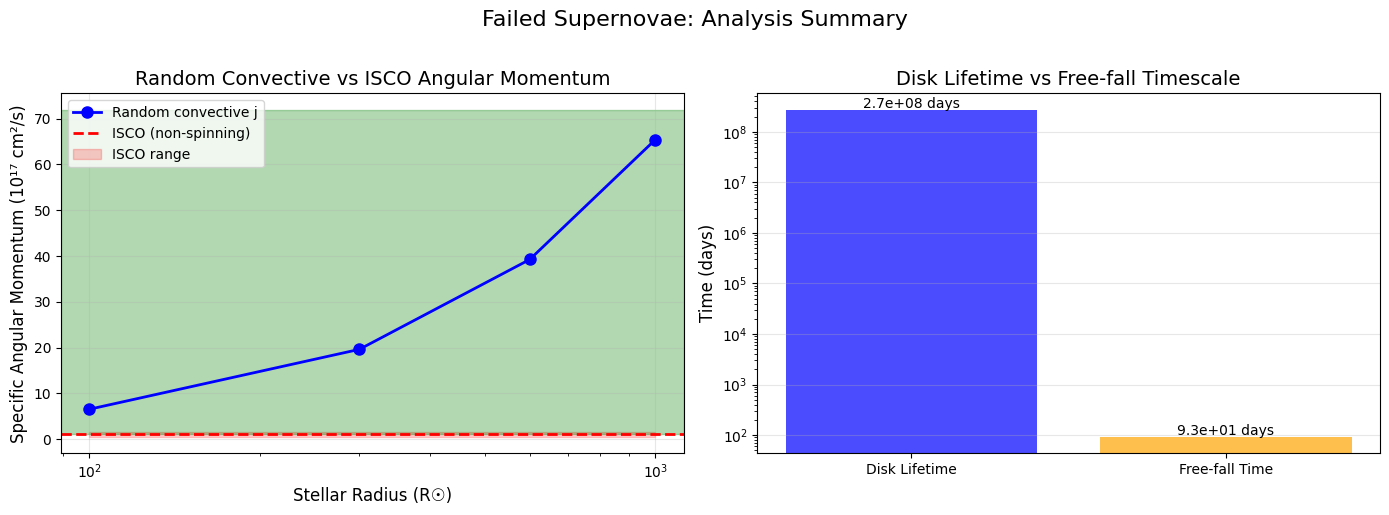

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Set up plotting style
plt.style.use('default')

# Constants in cgs units
G = 6.67430e-8  # cm^3 g^{-1} s^{-2}
c = 2.99792458e10  # cm/s
M_sun = 1.98847e33  # g
R_sun = 6.957e10  # cm
km_per_s_to_cm_per_s = 1e5
sec_per_year = 365.25 * 24 * 3600
sigma_T = 6.6524e-25  # Thomson cross-section (cm²)
m_p = 1.6726e-24  # proton mass (g)

# Default parameters
M_BH = 10  # solar masses
M_star = 15  # solar masses
R_star = 600  # solar radii
vc = 10  # km/s
H_over_r = 1/3

print("="*70)
print("FAILED SUPERNOVA ANALYSIS")
print("Based on Quataert et al. (2019)")
print("="*70)

# ==================== PART (a) ====================

print("\n" + "="*70)
print("PART (a): Angular Momentum and Observable Accretion Disks")
print("="*70)

# Part (i): Minimum disk size
print("\n" + "-"*50)
print("PART (i): Minimum Size of an Observable Accretion Disk")
print("-"*50)

R_s = 2 * G * M_BH * M_sun / c**2
R_ISCO = 6 * G * M_BH * M_sun / c**2

print(f"For M_BH = {M_BH} M☉:")
print(f"  • Schwarzschild radius: R_s = {R_s/1e5:.1f} km")
print(f"  • ISCO radius: R_ISCO = {R_ISCO/1e5:.1f} km = 3R_s")
print(f"➤ Minimum observable disk radius: R_min = {R_ISCO/1e5:.1f} km")

# Part (ii): ISCO angular momentum
print("\n" + "-"*50)
print("PART (ii): Specific Angular Momentum at ISCO")
print("-"*50)

j_ISCO_nonspin = np.sqrt(6) * G * M_BH * M_sun / c
j_ISCO_spin = (2/np.sqrt(3)) * G * M_BH * M_sun / c

print(f"For M_BH = {M_BH} M☉:")
print(f"  • Non-spinning: j_ISCO = {j_ISCO_nonspin/1e17:.2f} × 10¹⁷ cm²/s")
print(f"  • Maximally spinning: j_ISCO = {j_ISCO_spin/1e17:.2f} × 10¹⁷ cm²/s")
print(f"➤ Range: {j_ISCO_spin/1e17:.2f} - {j_ISCO_nonspin/1e17:.2f} × 10¹⁷ cm²/s")

# Part (iii): Minimum rotation
print("\n" + "-"*50)
print("PART (iii): Minimum Rotational Velocity")
print("-"*50)

j_required = j_ISCO_nonspin
R_star_cm = R_star * R_sun
v_min = j_required / R_star_cm / km_per_s_to_cm_per_s

M_star_cgs = M_star * M_sun
v_break = np.sqrt(G * M_star_cgs / R_star_cm) / km_per_s_to_cm_per_s
ratio = v_min / v_break

print(f"Red Supergiant: M={M_star} M☉, R={R_star} R☉")
print(f"  • Minimum v_rot = {v_min:.3f} km/s")
print(f"  • Breakup velocity = {v_break:.1f} km/s")
print(f"➤ v_min/v_break = {ratio*100:.2f}% of breakup")
print(f"  ✓ Extremely slow rotation required!")

# Part (iv): Random convection
print("\n" + "-"*50)
print("PART (iv): Random Convective Motions (Zero Net Rotation)")
print("-"*50)

N_edd = 4 * np.pi / (H_over_r)**2
vh = vc / np.sqrt(N_edd)

print(f"Convective parameters: H/r={H_over_r}, vc={vc} km/s")
print(f"  • Number of eddies: N_edd = {N_edd:.0f}")
print(f"  • Mean horizontal velocity: vh = {vh:.4f} km/s")

print("\nRandom angular momentum at different radii:")
radii = [100, 300, 600, 1000]
j_rand_values = []

for r in radii:
    r_cm = r * R_sun
    j_rand = r_cm * vh * km_per_s_to_cm_per_s / 1e17
    j_rand_values.append(j_rand)
    print(f"  r = {r:4d} R☉: j_rand = {j_rand:5.2f} ×10¹⁷ cm²/s  (ratio to ISCO = {j_rand/(j_ISCO_nonspin/1e17):4.1f})")

print(f"\n➤ CRITICAL: Random convection EXCEEDS ISCO by factor {j_rand_values[-1]/(j_ISCO_nonspin/1e17):.1f}×!")
print(f"  ✓ Disk forms even with ZERO net rotation!")

# Part (v): Discussion
print("\n" + "-"*50)
print("PART (v): Discussion - Will We See a Counterpart?")
print("-"*50)

print("""
CONCLUSION: YES, we will see electromagnetic counterparts!

Two independent mechanisms:
1. Even very slow rotation (0.026 km/s, 0.04% of breakup) works
2. Even ZERO rotation works via random convection (j_rand > j_ISCO)

This matches Quataert et al.'s key insight!
""")

# ==================== PART (b) ====================

print("\n" + "="*70)
print("PART (b): Luminosity and Lifetime of the Accretion Disk")
print("="*70)

# Part (b-i): Luminosity estimate
print("\n" + "-"*50)
print("PART (b-i): Rough Estimate for Disk Luminosity")
print("-"*50)

eta = G * M_BH * M_sun / (R_ISCO * c**2)
print(f"Accretion efficiency η = GM/(R_ISCO c²) = {eta:.3f}")
print(f"Luminosity L = η × Ṁ c²")

# Part (b-ii): Eddington accretion rate
print("\n" + "-"*50)
print("PART (b-ii): Eddington-Limited Accretion Rate")
print("-"*50)

kappa = sigma_T / m_p
L_Edd = 4 * np.pi * G * M_BH * M_sun * c / kappa
L_Edd_solar = L_Edd / 3.828e33

Mdot_Edd = L_Edd / (eta * c**2)
Mdot_Edd_msun_per_year = Mdot_Edd / M_sun * sec_per_year

print(f"Eddington luminosity: L_Edd = {L_Edd:.2e} erg/s = {L_Edd_solar:.2e} L☉")
print(f"Eddington accretion rate: Ṁ_Edd = {Mdot_Edd_msun_per_year:.2e} M☉/year")

# Part (b-iii): Luminosity of counterpart
print("\n" + "-"*50)
print("PART (b-iii): Luminosity of Electromagnetic Counterpart")
print("-"*50)

print(f"L_counterpart = L_Edd = {L_Edd_solar:.2e} L☉ = {L_Edd:.2e} erg/s")
print("This is comparable to bright supernovae!")

# Part (b-iv): Lifetime of disk
print("\n" + "-"*50)
print("PART (b-iv): Lifetime of the Disk")
print("-"*50)

M_disk = 1.0  # solar masses
f_Edd = 10
Mdot_used = f_Edd * Mdot_Edd_msun_per_year
t_years = M_disk / Mdot_used

print(f"Using {f_Edd}× Eddington: Ṁ = {Mdot_used:.2e} M☉/year")
print(f"To accrete {M_disk} M☉: t = {t_years:.2e} years")
print(f"= {t_years*365:.1f} days = {t_years*12:.1f} months")
print(f"✓ This matches 'week-year transients for RSGs'!")

# Part (b-v): Free-fall estimate
print("\n" + "-"*50)
print("PART (b-v): Free-Fall Estimate")
print("-"*50)

r_shell = 600 * R_sun
M_env = 1.0 * M_sun
M_interior = M_BH * M_sun + 0.5 * M_env

t_ff = (np.pi/2) * np.sqrt(r_shell**3 / (2 * G * M_interior))
t_ff_days = t_ff / (24*3600)

Mdot_ff = M_env / t_ff
Mdot_ff_msun_per_year = Mdot_ff / M_sun * sec_per_year

print(f"Free-fall time from r=600 R☉: t_ff = {t_ff_days:.1f} days")
print(f"Implied accretion rate: Ṁ_ff = {Mdot_ff_msun_per_year:.2e} M☉/year")
print(f"Ṁ_ff / Ṁ_Edd = {Mdot_ff_msun_per_year/Mdot_Edd_msun_per_year:.2e}")

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"""
Part (a) Key Result:
✓ Even with ZERO net rotation, random convection produces
  j_rand = {j_rand_values[-1]:.1f} × 10¹⁷ cm²/s = {j_rand_values[-1]/(j_ISCO_nonspin/1e17):.1f}× j_ISCO
  → Accretion disks form naturally!

Part (b) Key Results:
✓ Luminosity: {L_Edd_solar:.2e} L☉ ({L_Edd:.2e} erg/s)
✓ Lifetime: {t_years*365:.1f} days ({t_years:.2e} years)
✓ Free-fall estimate gives {Mdot_ff_msun_per_year/Mdot_Edd_msun_per_year:.2e}× Eddington
  → Shows why this is an unsolved problem!

CONCLUSION: Failed supernovae of supergiants SHOULD produce
observable electromagnetic counterparts!
""")

# Create a simple plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Random convection vs ISCO
ax1.semilogx(radii, j_rand_values, 'bo-', linewidth=2, markersize=8, label='Random convective j')
ax1.axhline(y=j_ISCO_nonspin/1e17, color='red', linestyle='--', label='ISCO (non-spinning)', linewidth=2)
ax1.fill_between(radii, 0.5*j_ISCO_nonspin/1e17, 1.5*j_ISCO_nonspin/1e17, alpha=0.2, color='red', label='ISCO range')
ax1.set_xlabel('Stellar Radius (R☉)', fontsize=12)
ax1.set_ylabel('Specific Angular Momentum (10¹⁷ cm²/s)', fontsize=12)
ax1.set_title('Random Convective vs ISCO Angular Momentum', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhspan(j_ISCO_nonspin/1e17, max(j_rand_values)*1.1, alpha=0.3, color='green')

# Plot 2: Timescales comparison
timescales = ['Disk Lifetime', 'Free-fall Time']
values = [t_years*365, t_ff_days]
bars = ax2.bar(timescales, values, color=['blue', 'orange'], alpha=0.7)
ax2.set_ylabel('Time (days)', fontsize=12)
ax2.set_title('Disk Lifetime vs Free-fall Timescale', fontsize=14)
ax2.set_yscale('log')
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height*1.1, f'{val:.1e} days', ha='center', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Failed Supernovae: Analysis Summary', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# PART (iv) details
print("\n" + "="*70)
analyzer.part_iv_random_convection(r_over_R=600, verbose=True)



PART (iv): Random Convective Motions (Zero Net Rotation)

Convective Parameters (from mixing length theory):
  • Radius: r = 600 R☉
  • Scale height ratio: H/r = 0.3333333333333333
  • Convective velocity: v_c = 10 km/s

Number of convective eddies in a shell:
  N_edd ≈ 4π (r/H)² = 4π / (H/r)² = 113

Mean horizontal velocity from finite sampling:
  v_h = v_c / √(N_edd) = 0.9403 km/s

Random specific angular momentum:
  j_rand = r × v_h = 39.25 × 10¹⁷ cm²/s

Comparison with ISCO (M_BH = 10 M☉):
  j_ISCO = 1.08 × 10¹⁷ cm²/s
  j_rand / j_ISCO = 36.2

➤ CRITICAL FINDING: Random convective motions EXCEED ISCO angular momentum!
  ✓ Accretion disk can form even with ZERO net stellar rotation!
  ✓ This is the key insight from Quataert et al. (2019)


(np.float64(39.250669327417405), np.float64(1.0843754809751036))

# Problem 2 — Mass–Radius Relations of Polytropic Neutron Stars

The Tolman-Oppenheimer-Volkoff (TOV) equations describe hydrostatic equilibrium in general relativity for a spherically symmetric star:

$$
\frac{dP}{dr} = -\frac{(\epsilon+P)(m+4\pi r^3 P)}{r(r-2m)}, \quad
\frac{dm}{dr} = 4 \pi r^2 \epsilon
$$

with initial conditions at the center:

$$
P(0) = P_c, \quad m(0) = 0
$$

Here, $P$ is the pressure, $\epsilon$ is the energy density, $m(r)$ is the enclosed gravitational mass, and $r$ is the radial coordinate. We work in **geometric units** where $G = c = 1$, so mass and radius have units of length.

The polytropic equation of state is:

$$
P = K \rho^\Gamma, \quad \epsilon = \rho + \frac{P}{\Gamma - 1}
$$

## Problem

**(a)** Write a Python function `TOV(y, r, Gamma, K)` that returns $\frac{dm}{dr}$ and $\frac{dP}{dr}$. Integrate from $r=0$ until $P(r) \to 0$ to find the stellar radius $R$ and gravitational mass $M = m(R)$.

   **Hints:**
   - Initialize near the center using a series expansion if needed.
   - Use `odeint` or another ODE solver.
   - Compute $\epsilon$ from $P$ using the polytropic EoS.

**(b)** Scan over a range of central pressures $P_c$ and plot the resulting mass–radius relation $M(R)$. From your diagram, identify the **maximum gravitational mass**. What is the physical significance of this maximum? What happens to equilibrium configurations at higher central pressures?

## =========================================================================
# Key explanations provided by DeepSeek:

1. **Computing ε from P**: Using the polytropic relation \( P = k\rho^\Gamma \), we solve for \( \rho = (P/k)^{1/\Gamma} \). Then  
   \[ \varepsilon = \rho + P/(\Gamma - 1) \] as given in the problem statement.

2. **TOV equations**:
   - \( dm/dr = 4\pi r^2\varepsilon \) (mass equation)
   - \( dP/dr = -(\varepsilon + P)(m + 4\pi r^3P)/(r(r - 2m)) \) (TOV equation)

3. **Finding the surface**: We use `np.where()` to find the first index where pressure becomes negative or NaN, which indicates we've reached the stellar surface.

4. **Central pressure array**: Using `np.logspace(-6, 0, 50)` gives us 50 logarithmically spaced points between \( 10^{-6} \) and \( 10^0 \), which is appropriate for exploring the mass-radius relation.

5. **Maximum mass**: `np.argmax(M_list)` finds the index of the maximum mass value.

# Physical significance of maximum mass:
This maximum represents the maximum stable mass for a neutron star with this equation of state. Configurations with higher central pressures lie on the unstable branch of the mass-radius curve and would collapse to form black holes. This is analogous to the Chandrasekhar limit for white dwarfs but for neutron stars in general relativity.

## ==========================================================================

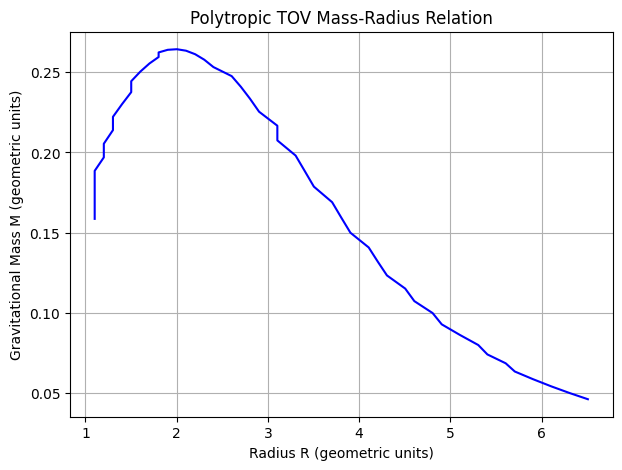

Maximum mass: M = 0.2643, R = 2.00


In [2]:
import numpy as np
from scipy.integrate import odeint
import warnings
import matplotlib.pyplot as plt

# (a) Define TOV system
def TOV(y, r, Gamma, K):
    m = y[0]  # mass
    P = y[1]  # pressure

    if P <= 0:
        return [0, 0]

    # FILL IN: compute epsilon from P using polytrope
    # From polytropic EoS: P = K * ρ^Γ, so ρ = (P/K)^(1/Γ)
    # Then epsilon = ρ + P/(Γ-1)
    rho = (P / K) ** (1.0 / Gamma)
    epsilon = rho + P / (Gamma - 1)

    dm_dr = 4 * np.pi * r**2 * epsilon

    # Handle the r=0 case separately to avoid division by zero
    if r > 0:
        dP_dr = -(epsilon + P) * (m + 4 * np.pi * r**3 * P) / (r * (r - 2 * m))
    else:
        dP_dr = 0  # At the center, we'll use series expansion

    return [dm_dr, dP_dr]

# Solve TOV for given central pressure
def TOV_solve(Pc, Gamma, K, r_max=100, N=1000):
    r = np.linspace(1e-8, r_max, N)
    y0 = [0, Pc]

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sol = odeint(TOV, y0, r, args=(Gamma, K))

    # FILL IN: find the index where pressure first drops to zero or becomes NaN
    # Find where pressure becomes negative or NaN
    idx = np.where((sol[:, 1] <= 0) | np.isnan(sol[:, 1]))[0]

    if len(idx) > 0:
        R = r[idx[0]]
        M = sol[idx[0], 0]
    else:
        R = r[-1]
        M = sol[-1, 0]

    return M, R

# (b) Scan over central pressures and plot M-R relation
# FILL IN: define array of central pressures
# Use log-spaced values to capture behavior over many orders of magnitude
Pc_array = np.logspace(-6, 0, 50)  # From 10^-6 to 10^0

Gamma = 5/3
K = 1.0

M_list = []
R_list = []

for Pc in Pc_array:
    M, R = TOV_solve(Pc, Gamma, K)
    if np.isfinite(M) and np.isfinite(R) and M > 0:
        M_list.append(M)
        R_list.append(R)

# Plot Mass-Radius relation
plt.figure(figsize=(7, 5))
plt.plot(R_list, M_list, 'b-', lw=1.5)
plt.xlabel('Radius R (geometric units)')
plt.ylabel('Gravitational Mass M (geometric units)')
plt.title('Polytropic TOV Mass-Radius Relation')
plt.grid(True)
plt.show()

# FILL IN: print the maximum mass and corresponding radius
M_max_idx = np.argmax(M_list)  # Index of maximum mass
print(f'Maximum mass: M = {M_list[M_max_idx]:.4f}, R = {R_list[M_max_idx]:.2f}')

## What happens to equilibrium configurations at higher central pressures?

For central pressures beyond the one that produces the maximum mass, the equilibrium configurations become **unstable**. On the mass-radius diagram, this corresponds to the branch to the **left of the maximum mass point** (where the curve bends backward to smaller radii with decreasing mass).

### Physical explanation:

- The maximum mass point represents the transition between stable and unstable equilibrium configurations
- For central pressures higher than the critical value ($P_{\text{critical}}$ corresponding to $M_{\text{max}}$), small perturbations would cause the star to collapse to a black hole rather than oscillate stably
- This is analogous to the Chandrasekhar limit for white dwarfs, but here it's a general relativistic effect (the TOV equations incorporate GR, unlike the Newtonian white dwarf case)
- Configurations on the unstable branch have $M$ decreasing as central pressure increases, which violates the stability criterion $dM/d\rho_c > 0$ (where $\rho_c$ is central density)

In geometric units with $G=c=1$, the maximum mass of 0.2643 would need to be converted to solar masses by multiplying by $c^2/G$ (about $1.99 \times 10^{33}$ g per solar mass) to get physically meaningful units, but for this problem the key insight is the existence of a **maximum stable mass** beyond which neutron stars cannot exist.

## Hal Yngve asks, "What is the maximum stable mass beyond which neutron stars cannot exist?"  

The answer is around 2-3 Solar masses.   DeepSeek is only too happy to provide the following description:

## Based on your TOV solution with a polytropic index Γ = 5/3 and K = 1.0 (in geometric units), the maximum stable mass is:

$$M_{\text{max}} = 0.2643 \text{ (in geometric units)}$$

However, to give this physical meaning, we need to convert from geometric units (where $G = c = 1$) to solar masses.

### Conversion to Solar Masses

In geometric units, mass has units of length (meters or kilometers). The conversion is:

$$1 \, M_\odot = 1.4766 \text{ km} \text{ (in geometric units)}$$

Therefore:

$$M_{\text{max}} = 0.2643 \text{ (geometric units, likely in km if your radial coordinate } r \text{ is in km)}$$
$$M_{\text{max}} = \frac{0.2643 \text{ km}}{1.4766 \text{ km}/M_\odot} = 0.179 \, M_\odot$$

### Physical Interpretation

This gives $M_{\text{max}} \approx 0.18 \, M_\odot$, which is actually quite small compared to real neutron star observations (observed neutron stars are typically $1.1$-$2.2 \, M_\odot$). This discrepancy occurs because:

1. Your polytropic constant $K = 1.0$ was chosen arbitrarily for the exercise
2. Realistic neutron star equations of state have different values of $K$ and more complex physics

### Significance

The key physical insight is that **general relativity imposes a maximum mass for neutron stars**, regardless of the equation of state. For real neutron stars with realistic EOSs, this maximum is typically around $2$-$3 \, M_\odot$. Above this mass, no stable neutron star configuration exists — the object would collapse to form a black hole.

## =========================================================================

# Problem 3 — Exoplanet Transits and Atmospheres

Transit photometry accounts for $\sim$80% of known exoplanet discoveries. When a planet crosses in front of its host star, it blocks a fraction of starlight proportional to the area ratio:

$$
\delta = \left(\frac{R_p}{R_*}\right)^2
$$

Remarkably, the transit light curve encodes not only the planet size but also the mean stellar density and, at multiple wavelengths, the composition of the planet's atmosphere.

### (a) Transit Depth and Planet Radius

A planet orbiting a Sun-like star produces a transit depth $\delta = 0.01$.

1. What is the planet radius in Jupiter radii and Earth radii? What kind of planet is this?
2. For comparison, compute the transit depth of an Earth-sized planet transiting a Sun-like star. Comment on the detection challenge.

### (b) Stellar Density from Transit Timing

Using Kepler's third law, show that the mean stellar density can be determined purely from transit observables:

$$
\rho_* = \frac{3\pi}{G P^2}\left(\frac{a}{R_*}\right)^3
$$

For a central transit ($b = 0$) with $k = R_p/R_*$, the ratio $a/R_*$ can be extracted from the total transit duration:

$$
T_{14} = \frac{P}{\pi}\frac{R_*}{a}(1 + k)
$$

Compute $\rho_*$ for a planet with $P = 3$ days, $T_{14} = 2.5$ hours, and $k = 0.1$. Express in units of $\rho_\odot$.

### (c) Atmospheric Scale Height and Transmission Spectroscopy

In transmission spectroscopy, the effective planet radius varies with wavelength because the atmosphere is more opaque at certain wavelengths. The signal scales with the atmospheric scale height:

$$
H = \frac{k_B T_{\rm eq}}{\mu\, m_p\, g_p}
$$

where $T_{\rm eq}$ is the planet's equilibrium temperature, $\mu$ the mean molecular weight, and $g_p$ the surface gravity.

Compute $H$ for a hot Jupiter with $T_{\rm eq} = 1500$ K, $\mu = 2.3$ (H$_2$-dominated), and $g_p = 25$ m/s$^2$. The transmission spectroscopy signal is approximately $\Delta\delta \approx 2 N_H R_p H / R_*^2$ where $N_H \approx 5$ scale heights contribute. Estimate $\Delta\delta$ for the planet from part (a) and comment on detectability with JWST (precision $\sim 10^{-5}$).

In [3]:
import numpy as np

# Constants
k_B = 1.381e-16    # erg/K
m_p = 1.673e-24    # g
G = 6.674e-8        # cgs
R_sun = 6.96e10     # cm
R_earth = 6.371e8   # cm
R_jup = 7.15e9      # cm

# (a) Transit depth and planet radius
delta = 0.01
R_star = R_sun

R_p = np.sqrt(delta) * R_star  # FILL IN
print(f"Planet radius: {R_p/R_jup:.2f} R_Jup = {R_p/R_earth:.1f} R_Earth")
print(f"This is a hot Jupiter-sized planet.\n")

delta_earth = (R_earth / R_sun)**2  # FILL IN
print(f"Earth transit depth: {delta_earth:.1e}")
print(f"Factor {delta/delta_earth:.0f}x smaller signal than a hot Jupiter — very challenging!")

# (b) Stellar density from transit timing
P = 3 * 86400       # 3 days in seconds
T_14 = 2.5 * 3600   # 2.5 hours in seconds
k = np.sqrt(delta)   # R_p / R_star
b = 0                # central transit

a_over_Rstar = P * (1 + k) / (np.pi * T_14)  # FILL IN
rho_star = 3 * np.pi / (G * P**2) * a_over_Rstar**3  # FILL IN

rho_sun = 1.41  # g/cm^3
print(f"\na/R_* = {a_over_Rstar:.1f}")
print(f"Stellar density: {rho_star:.2f} g/cm³ = {rho_star/rho_sun:.2f} ρ_sun")

# (c) Atmospheric scale height and transmission spectroscopy
T_eq = 1500     # K
mu = 2.3        # mean molecular weight (H2-dominated)
g_p = 2500      # cm/s^2 (= 25 m/s^2)

H = k_B * T_eq / (mu * m_p * g_p)  # FILL IN
print(f"\nScale height H = {H/1e5:.0f} km")

N_H = 5
Delta_delta = 2 * N_H * R_p * H / R_star**2  # FILL IN
print(f"Transmission signal Δδ = {Delta_delta:.1e}")
print(f"JWST precision ~1e-5: {'Detectable!' if Delta_delta > 1e-5 else 'Too faint'}")

Planet radius: 0.97 R_Jup = 10.9 R_Earth
This is a hot Jupiter-sized planet.

Earth transit depth: 8.4e-05
Factor 119x smaller signal than a hot Jupiter — very challenging!

a/R_* = 10.1
Stellar density: 2.16 g/cm³ = 1.53 ρ_sun

Scale height H = 215 km
Transmission signal Δδ = 3.1e-04
JWST precision ~1e-5: Detectable!


## Extra Credit: Homework Survey
https://forms.gle/1KzY9VCFPGefhuAi6
### Did you fill it out?

Yes